Testing out some of the math from Alex Greaney's document

In [12]:
# get values from hdf5
import numpy as np
import h5py # https://docs.h5py.org/en/stable/quick.html to read hdf5 files
import matplotlib.pyplot as plt
import importlib
import helpers
importlib.reload(helpers)

read_file = True
if read_file:
    # inputfile='./data-bin/kappa_555_nosym_phono3py.hdf5'
    inputfile='./data-bin/kappa_101010_nosym_phono3py.hdf5'
    data = helpers.get_data_hdf5(inputfile=inputfile)
    
    # choose 270K for now
    gamma = data.gamma[27,:,:]                  # Hz
    gv = data.group_velocity                    # A * Hz 
    # number of qpoints, number of polarizations
    Nq,Nb = gv.shape[:2] 
    cv = data.heat_capacity[27,:,:]             # eV / K
    freq = data.frequency                       # Hz (ordinal frequency)
    T = data.temperature                        # K

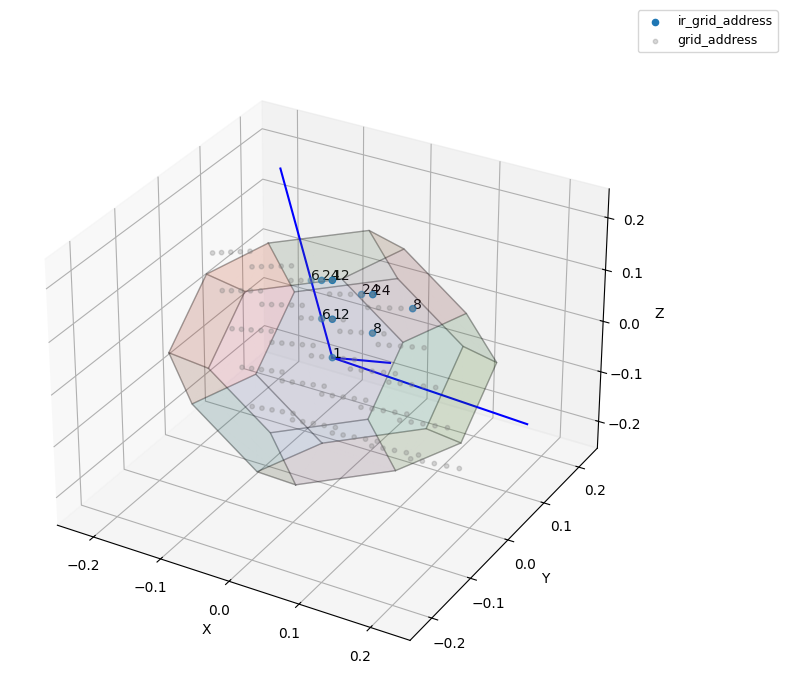

In [13]:
# visualize mesh and irreducible mesh points
import numpy as np
import h5py
import yaml

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# %matplotlib ipympl
# plot bz using this tutorial (which uses scipy with qhull to calculate voroni)
# http://staff.ustc.edu.cn/~zqj/posts/howto-plot-brillouin-zone/

def get_brillouin_zone_3d(cell):
    """
    https://en.wikipedia.org/wiki/Wigner%E2%80%93Seitz_cell
    https://docs.scipy.org/doc/scipy/reference/tutorial/spatial.html#voronoi-diagrams

    cell : array_like, shape (3, 3)

    bz_vertices : ndarray
        Coordinates of the BZ vertices.
    bz_ridges : list of ndarray
        Each entry is an array of vertices forming a closed edge loop.
    bz_facets : list of ndarray
        Each entry is an array of vertices forming a facet of the BZ.
    """
    cell = np.asarray(cell, dtype=float)
    assert cell.shape == (3, 3)

    px, py, pz = np.tensordot(cell, np.mgrid[-1:2, -1:2, -1:2], axes=[0, 0])
    points = np.c_[px.ravel(), py.ravel(), pz.ravel()]

    from scipy.spatial import Voronoi
    vor = Voronoi(points)

    bz_facets = []
    bz_ridges = []
    bz_vertices = []

    for pid, rid in zip(vor.ridge_points, vor.ridge_vertices):
        # The 14th input point (index 13) is [0, 0, 0].
        # Ridges adjacent to the origin define the BZ faces.
        if pid[0] == 13 or pid[1] == 13:
            bz_ridges.append(vor.vertices[np.r_[rid, [rid[0]]]])
            bz_facets.append(vor.vertices[rid])
            bz_vertices += rid

    bz_vertices = list(set(bz_vertices))
    return vor.vertices[bz_vertices], bz_ridges, bz_facets

def plot_brillouin_zone(cell):
    """
    Compute and plot the first Brillouin Zone for the given real-space cell.

    Parameters
    ----------
    cell : array_like, shape (3, 3)
        Real-space basis vectors (one per row).
    """
    cell = np.asarray(cell, dtype=float)

    # Reciprocal lattice basis vectors
    icell = np.linalg.inv(cell).T

    # Lengths of the reciprocal basis vectors (used to set axis limits)
    b1, b2, b3 = np.linalg.norm(icell, axis=1)

    # Get BZ vertices, ridges (edges), and facets
    v, e, f = get_brillouin_zone_3d(icell)
    return e,f,icell

yamlfile='/gscratch/ajense28/GK/Si-VASP/phono3py/result-555/ir_grid_points.yaml'
hdf5file='/gscratch/ajense28/GK/Si-VASP/phono3py/result-sym-555/grid_address-m555.hdf5'
with open(yamlfile, 'r') as f:
    yamldata = yaml.safe_load(f)
reciprocal_lattice = np.array([q for q in yamldata['reciprocal_lattice'][:]])
ir_grid_address = np.array([[q for q in grid_point['grid_address']] for grid_point in yamldata['ir_grid_points'][:]])
ir_qpoints = np.array([[q for q in grid_point['q-point']] for grid_point in yamldata['ir_grid_points'][:]])
ir_weights = np.array([grid_point['weight'] for grid_point in yamldata['ir_grid_points'][:]])

hdf5data = h5py.File(hdf5file, 'r')
keys=hdf5data.keys() # read the hdf5 keys like a python dictionary
grid_address=np.array([q for q in hdf5data['grid_address'][:]] if 'grid_address' in keys else None, dtype=np.float64)*0.2
mesh=np.array(hdf5data['mesh'][:] if 'mesh' in keys else None, dtype=np.float64)
grid_mapping_table=np.array([q for q in hdf5data['grid_mapping_table'][:]] if 'grid_mapping_table' in keys else None, dtype=np.float64)

# shape to primitive lattice
def convert_to_pa(reciprocal_lattice,array):
    a = np.array([q[0]*reciprocal_lattice[0]+q[1]*reciprocal_lattice[1]+q[2]*reciprocal_lattice[2] for q in array])
    return a

# ir_grid_address_pa = convert_to_pa(reciprocal_lattice,ir_grid_address)*0.5
# grid_address_pa = convert_to_pa(reciprocal_lattice,grid_address)*0.5

# plt.close('all')
def plot_grid_3d(mesh, sym_mesh, xlabel=None, ylabel=None, zlabel=None, title=None,reciprocal_lattice=None,weights=None,cell=np.array([[     0.000000089984905,     2.700723247819465,     2.700723237168927 ],[     2.700723025703579,     0.000000306249005,     2.700723020876127 ],[     2.700723368579057,     2.700723374459082,    -0.000000036626935 ]])):
    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(111, projection='3d')

    # if reciprocal_lattice is not None: 
    #     for r in reciprocal_lattice:
    #         ax.plot([0,r[0]],[0,r[1]],[0,r[2]])
    
    e,f,icell=plot_brillouin_zone(cell)

    isym_mesh=np.zeros(sym_mesh.shape)
    for i,m in enumerate(sym_mesh):
        isym_mesh[i]=icell@m
    ax.scatter(isym_mesh[:, 0], isym_mesh[:, 1], isym_mesh[:, 2],
        c='tab:blue', s=20, label='ir_grid_address')
    imesh=np.zeros(mesh.shape)
    for i,m in enumerate(mesh):
        imesh[i]=icell@m
    ax.scatter(imesh[:, 0], imesh[:, 1], imesh[:, 2],
        c='gray', alpha=0.3, s=10, label='grid_address')
    if weights is not None: 
        for i,ga in enumerate(isym_mesh):
            ax.text(ga[0],ga[1],ga[2],s=f'{weights[i]}')
    
    # plot bz edges
    for xx in e:
        ax.plot(xx[:, 0], xx[:, 1], xx[:, 2], color='k', lw=1.0,alpha=0.2)

    # plot facets
    for ff in f:
        ax.plot_trisurf(ff[:,0],ff[:,1],ff[:,2],alpha=0.1)

    # plot basis vectors
    for b in icell:
        # print(b)
        ax.plot([0,b[0]],[0,b[1]],[0,b[2]],'b-')

    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if zlabel: ax.set_zlabel(zlabel)
    if title:  ax.set_title(title)

    ax.legend(loc=(1.0,1.0),fontsize=9)
    plt.tight_layout()
    plt.show()


    
plot_grid_3d(grid_address, ir_qpoints, xlabel='X', ylabel='Y', zlabel='Z',reciprocal_lattice=reciprocal_lattice,weights=ir_weights)

mean free path
$\lambda = v \otimes \tau$

In [14]:
def compute_mfp(gv,gamma):
    gamma = np.where(gamma > 0, gamma, -1)
    tau = np.where(gamma > 0, 1.0 / (2 * 2 * np.pi * gamma), 0)     # 1/(2pi Hz)
    if gv.shape[-1] == 3:
        mfp = np.zeros(gv.shape)
        for i in range(gv.shape[2]):
            mfp[:,:,i] = gv[:,:,i]*tau
    else:
        mfp = gv*tau
    return abs(mfp) # units of Angstrom, can only be positive
mfp = compute_mfp(gv,gamma)
print(mfp.shape)

(1000, 24, 3)


order all variables with ascending mean free path

In [15]:
# flatten and order variables with mfp
flatten_values = True
if flatten_values and mfp is not None:
    if mfp.shape == (125, 24, 3) or mfp.shape[-1] == 3:
        indices_x,indices_y,indices_z = (np.argsort(mfp[:,:,0].flatten()),np.argsort(mfp[:,:,1].flatten()),np.argsort(mfp[:,:,2].flatten()))
        mfp_i = np.array([mfp[:,:,0].flatten()[indices_x],mfp[:,:,1].flatten()[indices_y],mfp[:,:,2].flatten()[indices_z]])
        gv_i = np.array([gv[:,:,0].flatten()[indices_x],gv[:,:,1].flatten()[indices_y],gv[:,:,2].flatten()[indices_z]])
        cv_i = np.array([cv.flatten()[indices_x],cv.flatten()[indices_y],cv.flatten()[indices_z]])
        w_i = np.array([freq.flatten()[indices_x],freq.flatten()[indices_y],freq.flatten()[indices_z]])*2*np.pi
    else:
        indices = np.argsort(mfp.flatten())
        mfp_i = mfp.flatten()[indices]
        gv_i = np.mean(gv,axis=1)[indices]
        cv_i = cv.flatten()[indices]
        w_i = freq.flaten()[indices]*2*np.pi
print(mfp_i.shape)
    

(3, 24000)


primitive cell volume $V_{cell} = a \cdot b \times c$

In [22]:
def get_volume(inputfile='/gscratch/ajense28/GK/Si-VASP/phono3py/phono3py.yaml',read_file=False):
    read_file = False
    if read_file:
        import yaml
        with open(inputfile, 'r') as f:
            lattice = np.array(yaml.safe_load(f)['primitive_cell']['lattice'])
        Vcell = np.dot(lattice[:,0],np.cross(lattice[:,1],lattice[:,2]))
    else:
        Vcell = 157.59055665153235
    return Vcell
Vcell = get_volume()

thermal conductivity iso $\kappa_{iso}(\lambda) = \frac{1}{3} \sum^{j_\lambda}_{i=1} C_i | v_i | \lambda_i$

In [23]:
def compute_k_iso_i(cv_i,gv_i,mfp_i,Vcell,Nb,Nq):
    # expects all values to be ordered with ascending mfp and flattened
    if mfp.shape[0] == 3:
        k_iso_i = np.zeros(mfp.shape)
        for x in range(mfp.shape[-1]):
            Cv_i = cv_i[x] * Nb / (Vcell * Nq) 
            k_iso_i[x] = (1/3) * Cv_i * abs(gv_i[x]) * mfp_i[x]
    else:
        Cv_i = cv_i * Nb / (Vcell * Nq) 
        k_iso_i = (1/3) * Cv_i * abs(gv_i) * mfp_i
    return k_iso_i
k_iso_i = compute_k_iso_i(cv_i,gv_i,mfp_i,Vcell,Nb,Nq)
print(k_iso_i.shape)


(3, 24000)


In [25]:
def smearing(xvals,yvals,sigma=0.1):
# The spectrum is created by representing each sample frequency as 
# a Gaussian distribution and summing the distributions for all samples. 
    s = np.zeros(np.shape(xvals));
    for i,y in enumerate(yvals):
        s = s + (1./(np.sqrt(2.*np.pi)*sigma))*np.exp(-(1./2.)*((xvals-y)/sigma)**2.);
    return s

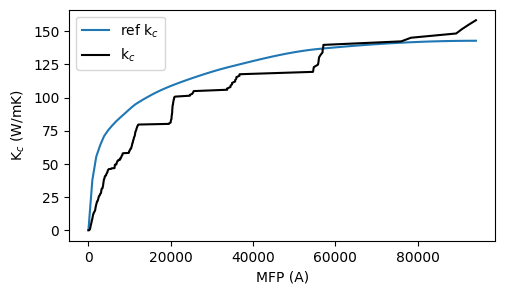

In [34]:
plt.close('all')
# computes the cumulative thermal conductivity
def compute_k_c(cv,gv,mfp,Vcell,Nb,Nq):
    eV2Watt=1.6022E-19
    mfp_norm = np.linalg.norm(mfp,axis=2)
    gv_norm = np.linalg.norm(gv,axis=2)
    k_s = cv * gv_norm * mfp_norm / Vcell
    mfp_l=np.sort(mfp_norm.flatten())
    y=np.array([]);ynext=0
    x = []
    k_c = [];kcnext=0
    for idx,l in enumerate(np.unique(mfp_l)):
        indices=np.array(mfp_norm-l == 0)
        for k in k_s[indices]:
            ynext+=np.sum(k*1)
            y=np.append(y,ynext)
            x=np.append(x,l)
            kcnext+=np.trapz(y,x)
            k_c = np.append(k_c,kcnext)
    return k_c*eV2Watt,mfp_l

# k_c,mfp_c = compute_k_c(cv,gv,mfp,Vcell,Nb,Nq)
# print(k_c.shape)
# inputfile='/gscratch/ajense28/GK/Si-VASP/phono3py/result-101010/kaccum_mfp_270.dat'
# [mfp_r,xx_r] = np.loadtxt(inputfile, comments='#', dtype=np.float64,usecols=(0,1),unpack=True,max_rows=100)

fig = plt.figure(figsize=(5.5,3))
# NA=6.02214076e23
plt.plot(mfp_r,xx_r,label="ref k$_c$")
plt.plot(mfp_c,k_c,'k-',label='k$_c$')
plt.ylabel(f'K$_c$ (W/mK)')
plt.xlabel(f'MFP (A)')
# plt.xscale('log',base=10)
# plt.xlabel(f'log$_1$$_0$(MFP)')
# plt.xscale('log',base=10)
plt.legend()
# plt.savefig('./Si_kappa_vs_mfp.png',format='png',dpi=150)
plt.show()



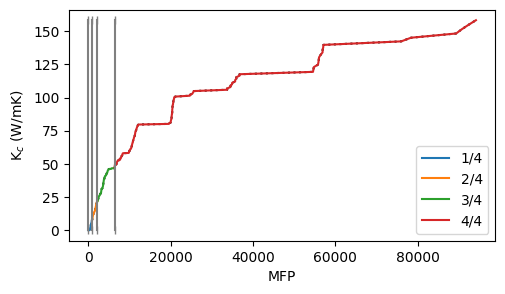

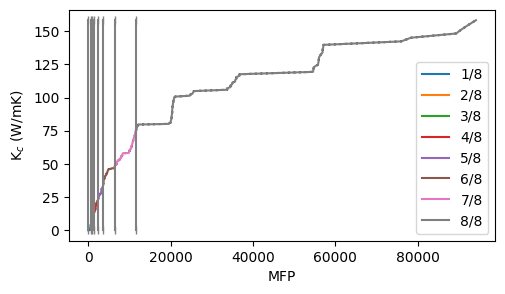

In [39]:
def plot_groups(Ng, mfp, k):
    # expects a vector for mfp and k_iso (ie .shape=3000,)
    k_frac = np.sum(k)/Ng
    if k_frac < np.max(k):
        print(f'uh oh {k_frac.round()} < {np.max(k).round()}')
    idx = 0; indices = np.zeros((Ng,2))
    for i in range(Ng):
        indices[i,0] = idx
        contribution = k[idx]
        while contribution <= k_frac and idx + 1 < k.size:
            idx +=1
            contribution += k[idx]
        idx +=1
        if indices[i,0] < k.size - 1:
            indices[i,1] = idx
        else:
            indices[i,1] = -1
    indices=np.array(indices,dtype=int)
    fig = plt.figure(figsize=(5.5,3))
    plt.plot(mfp,k,'k:')
    for l,g in enumerate(indices):
        if g[0] < k.size - 1:
            plt.plot(mfp[g[0]:g[1]],k[g[0]:g[1]],label=f'{l+1}/{Ng}')
        else:
            plt.plot(mfp[-1],k[-1],marker='.',label=f'{l+1}/{Ng}')
        plt.plot([mfp[g[0]],mfp[g[0]]],[np.min(k),np.max(k)],'grey',marker='|')
    plt.xscale('linear')#,base=10)
    # plt.xlim((2,4.5))
    plt.legend()#loc=(1,0))
    # plt.title(f'N_g = {Ng} groups of K$_c$')
    plt.xlabel(f'MFP')
    plt.ylabel(f'K$_c$ (W/mK)')
    # plt.savefig(f'./Si_kappa_vs_mfp_Ng{Ng}.png',format='png',dpi=150)
    plt.show()
plot_groups(4,mfp_c,k_c)
plot_groups(8,mfp_c,k_c)

In [ ]:
def compute_groups_indices(Ng, mfp_m, k_iso_m):
    # expects a vector for mfp and k_iso (ie .shape=3000,)
    k_frac = np.sum(k_iso_m)/Ng
    if k_frac < np.max(k_iso_m):
        print(f'uh oh {k_frac.round()} < {np.max(k_iso_m).round()}')
    idx = 0; indices = np.zeros((Ng,2))
    for i in range(Ng):
        indices[i,0] = idx
        contribution = k_iso_m[idx]
        while contribution <= k_frac and idx + 1 < k_iso_m.size:
            idx +=1
            contribution += k_iso_m[idx]
        # print(np.round(contribution/np.sum(k_iso_m),2))
        idx +=1
        if indices[i,0] < k_iso_m.size - 1:
            indices[i,1] = idx
        else:
            indices[i,1] = -1
    return np.array(indices,dtype=int)
mfp_m=np.mean(mfp_i,axis=0)
k_iso_m=np.mean(k_iso_i,axis=0)
Ng = 4
indices = compute_groups_indices(Ng=Ng,mfp_m=mfp_m,k_iso_m=k_iso_m)
print(indices)
mfp_m_log10 = np.log10(np.where(mfp_m>0,mfp_m,np.nan))
plt.plot(mfp_m_log10,k_iso_m,'k:')
for l,g in enumerate(indices):
    if g[0] < k_iso_m.size - 1:
        plt.plot(mfp_m_log10[g[0]:g[1]],k_iso_m[g[0]:g[1]],label=f'group {l+1}')
    else:
        plt.plot(mfp_m_log10[-1],k_iso_m[-1],marker='.',label=f'group {l+1}')
    plt.plot([mfp_m_log10[g[0]],mfp_m_log10[g[0]]],[np.min(k_iso_m),np.max(k_iso_m)],'grey',marker='|')
# plt.yscale('log',base=10)
# plt.xlim((2,4.5))
plt.legend(loc=(1,0))
plt.title(f'N_g = {Ng} groups of K_iso')
plt.xlabel(f'log10(MFP)')
plt.ylabel(f'K (W/m/K)')


uh oh 1.0 < 3.0


IndexError: invalid index to scalar variable.

In [ ]:
# compute all other values
def compute_psi_g(Nb,Vcell,Nm,gv_i,w_i,T,group_indices):
    hbar = 6.582119569e-16 # eV * s
    kB = 8.617333262e-5 # eV / K
    psi_g = np.zeros(group_indices.shape[0])
    for i,[g_min,g_max] in enumerate(group_indices):
        print(i,g_min,g_max)
        if g_max == -1:
            psi_g[i] = (Nb/(Vcell*Nm)) * np.sum(abs(gv_i[-1])*w_i[-1]*hbar/(np.exp((w_i[-1]*hbar)/(kB*T))-1))
        else:
            psi_g[i] = (Nb/(Vcell*Nm)) * np.sum(abs(gv_i[g_min:g_max])*w_i[g_min:g_max]*hbar/(np.exp((w_i[g_min:g_max]*hbar)/(kB*T))-1))
    return psi_g
compute_psi_g(Nb=Nb,Vcell=Vcell,Nm=Nq,gv_i=gv_i,w_i=w_i,T=270,group_indices=indices)

0 0 22712
1 22712 23801
2 23801 23973
3 23973 24000


array([1.41213693e+12, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [ ]:
import numpy as np
a=np.array([[1,2],[3,4],[5,6]]); 
print(a.shape)
for i in np.split(a,indices_or_sections=2,axis=1): 
    print(i);

(3, 2)
[[1]
 [3]
 [5]]
[[2]
 [4]
 [6]]
